In [1]:
'''
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA_400/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")
for file in file_list:
    print(f"Gefundene Datei: {file}")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")
'''

'\n# 📦 Schritt 1: Bibliotheken importieren\nimport pandas as pd\nimport glob\nimport os\n\n# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren\nfolder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA_400/"\nfile_pattern = os.path.join(folder_path, "Metrics_*.csv")\n\n# 📂 Schritt 3: Alle passenden CSV-Dateien finden\nfile_list = glob.glob(file_pattern)\nprint(f"{len(file_list)} Dateien gefunden.")\nfor file in file_list:\n    print(f"Gefundene Datei: {file}")\n\n# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen\nall_dfs = [pd.read_csv(file) for file in file_list]\nfull_df = pd.concat(all_dfs, ignore_index=True)\nprint("Daten erfolgreich zusammengeführt.")\ndisplay(full_df.head())\n\n# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen\naverage_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()\nprint("Durchschnittswerte berechnet.")\ndisplay(average_df.head())\n\n# 💾 Schritt 6: Ergebnis abspeicher

In [2]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DbSA,163.498,0.891,0.166,0.433,0.233,85.325,0.045,0.614
a10_o107_m5_an57_ar12,PSA,162.780,0.309,0.868,0.291,0.237,14.675,0.088,0.522
a10_o114_m6_an57_ar11,DbSA,290.878,0.927,0.164,0.459,0.071,85.614,0.067,0.849
a10_o114_m6_an57_ar11,PSA,310.708,0.323,0.886,0.439,0.177,14.386,0.148,0.819
a10_o128_m6_an51_ar13,DbSA,238.800,0.900,0.226,0.007,0.177,88.443,0.060,0.895
a10_o128_m6_an51_ar13,PSA,202.030,0.187,0.795,0.007,0.171,11.557,0.159,0.913
a10_o144_m6_an53_ar12,DbSA,153.957,0.768,0.235,0.503,0.208,63.568,0.064,0.577
a10_o144_m6_an53_ar12,PSA,167.980,0.657,0.309,0.495,0.154,36.432,0.109,0.629
a15_o170_m9_an80_ar18,DbSA,444.782,0.851,0.107,0.096,0.186,81.384,0.034,0.782
a15_o170_m9_an80_ar18,PSA,399.750,0.398,0.255,0.135,0.176,18.616,0.057,0.891


In [3]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
Algorithm,,,,,,,,
DbSA,571.204,0.821,0.152,0.232,0.193,78.046,0.047,0.722
PSA,635.659,0.449,0.393,0.236,0.172,21.954,0.083,0.790


In [4]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
Algorithm,,,,,,,,
DbSA,474.041,0.094,0.074,0.211,0.067,7.977,0.019,0.114
PSA,605.848,0.148,0.322,0.177,0.048,7.977,0.045,0.161


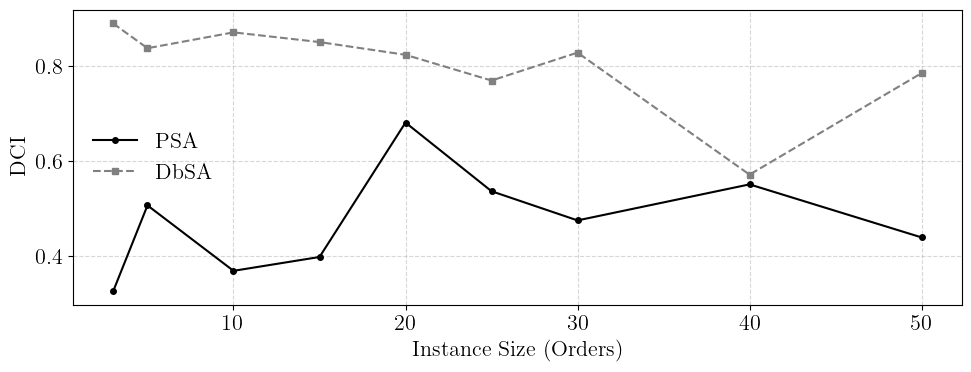

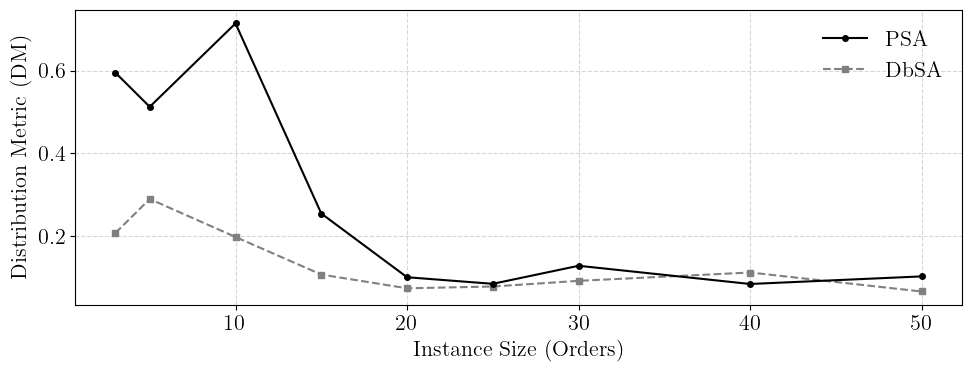

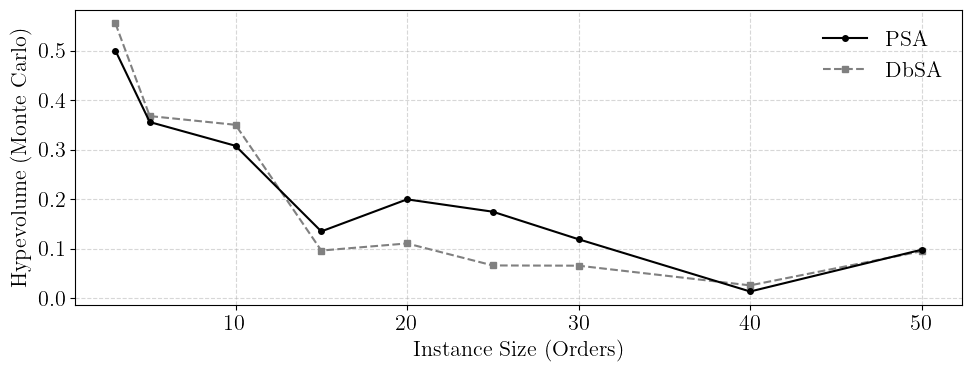

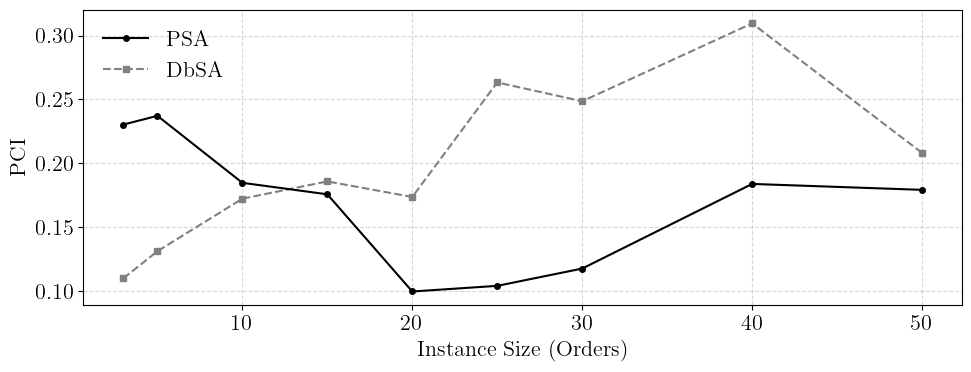

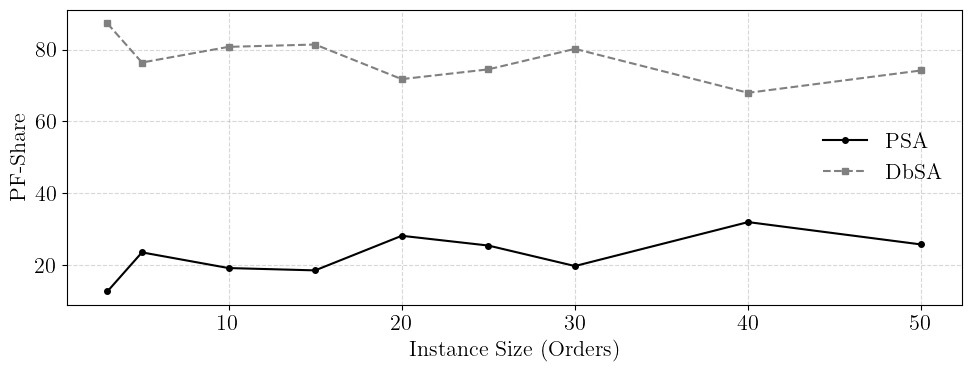

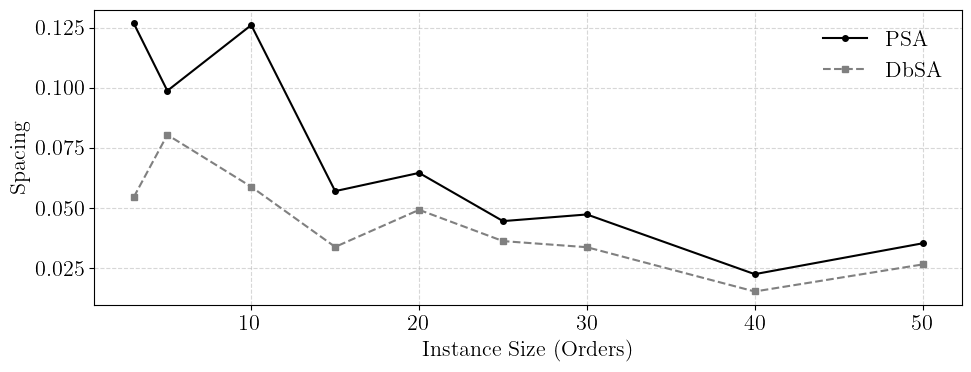

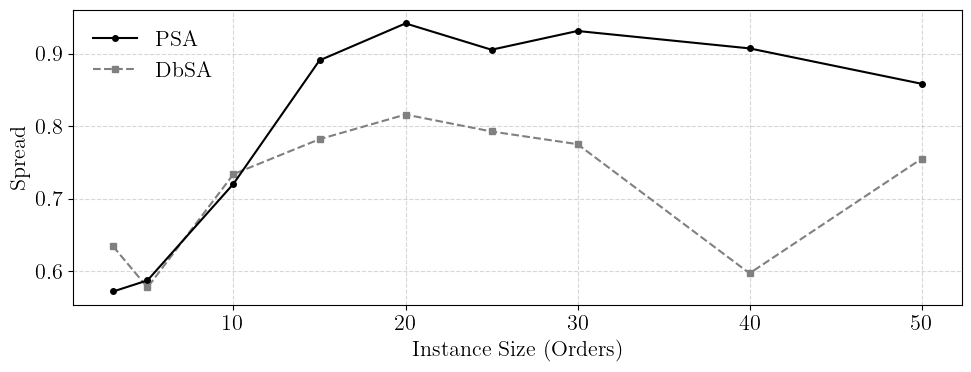

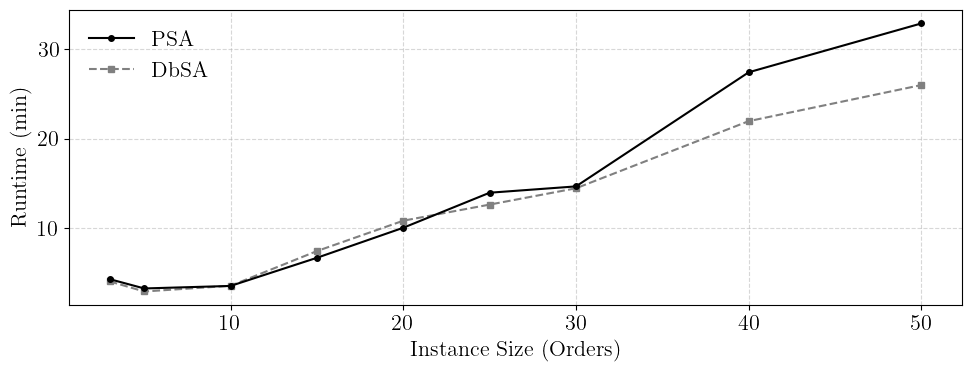

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 🎨 LaTeX-Stil global aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 16
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# ⏱️ Wenn "Improvement Time" vorhanden ist, umbenennen und in Minuten umrechnen
if "Improvement_Time" in df.columns:
    df["Runtime (min)"] = df["Improvement_Time"] / 60
    df.drop(columns=["Improvement_Time"], inplace=True)

# 📊 Instanzgröße extrahieren
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🔎 Alle Metriken außer diesen:
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Durchschnitt berechnen
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Farb-/Stilzuordnung
style_map = {
    "PSA": {"label": "PSA", "linestyle": "-", "color": "black", "marker": "o", "zorder": 3},
    "DbSA": {"label": "DbSA", "linestyle": "--", "color": "gray", "marker": "s", "zorder": 2},
}

# 📊 Plot für jede Metrik
for metric in metrics:
    plt.figure(figsize=(10, 4))

    for algo, style in style_map.items():
        subset = agg_df[agg_df["Algorithm"] == algo]
        plt.plot(
            subset["Instance_Size"], subset[metric],
            label=style["label"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            color=style["color"],
            markersize=4,
            linewidth=1.5,
            zorder=style["zorder"]
        )

    # 📏 Formatierung
    #plt.title(metric)
    plt.xlabel("Instance Size (Orders)")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="best", frameon=False)
    plt.tight_layout()

    # Optional: Speichern als PDF
    #plt.savefig(f"{metric.replace(' ', '_').lower()}_lineplot.pdf", dpi=300, bbox_inches="tight")

    plt.show()

<Figure size 600x400 with 0 Axes>

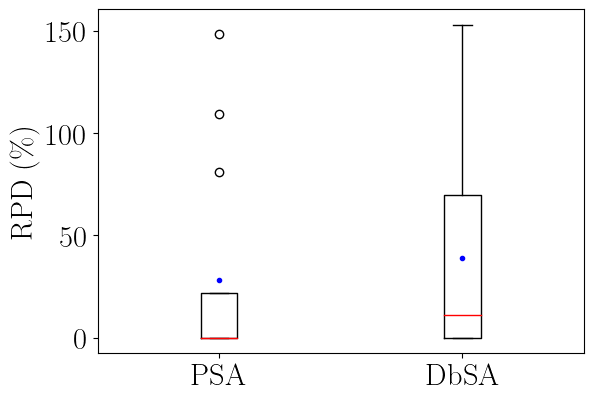


RPD-Werte für PCI – Algorithmus: PSA (absteigend sortiert):
                    Instance    PCI RPD
       a10_o114_m6_an57_ar11 148.427526
 a3_o80_m10_an10_ar9_reduced 109.400766
a5_o96_m10_an10_ar10_reduced  80.794447
       a10_o107_m5_an57_ar12   1.885139
       a10_o128_m6_an51_ar13   0.000000
       a10_o144_m6_an53_ar12   0.000000
       a15_o170_m9_an80_ar18   0.000000
     a20_o236_m12_an106_ar24   0.000000
     a25_o306_m13_an127_ar31   0.000000
     a30_o355_m18_an148_ar42   0.000000
     a40_o476_m22_an215_ar51   0.000000
     a50_o578_m28_an276_ar66   0.000000
  Algorithmus: PSA
    Q1: 0.0000
    Q2 (Median): 0.0000
    Mean: 28.3757
    Q3: 21.6125
    IQR: 21.6125
    Minimum: 0.0000
    Maximum: 148.4275
    Whisker min: 0.0000
    Whisker max: 1.8851
    Theoretical max whisker length (1.5 * IQR): 32.4187

RPD-Werte für PCI – Algorithmus: DbSA (absteigend sortiert):
                    Instance    PCI RPD
     a25_o306_m13_an127_ar31 152.996186
     a30_o355_m18_an14

<Figure size 600x400 with 0 Axes>

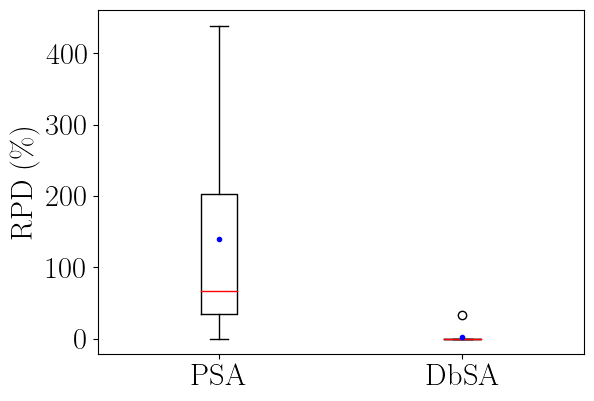


RPD-Werte für Distribution Metric (DM) – Algorithmus: PSA (absteigend sortiert):
                    Instance  Distribution Metric (DM) RPD
       a10_o114_m6_an57_ar11                    438.709590
       a10_o107_m5_an57_ar12                    422.026573
       a10_o128_m6_an51_ar13                    250.959454
 a3_o80_m10_an10_ar9_reduced                    186.470150
       a15_o170_m9_an80_ar18                    137.553246
a5_o96_m10_an10_ar10_reduced                     76.921860
     a50_o578_m28_an276_ar66                     55.164484
     a30_o355_m18_an148_ar42                     39.578203
     a20_o236_m12_an106_ar24                     36.156660
       a10_o144_m6_an53_ar12                     31.436579
     a25_o306_m13_an127_ar31                      8.326602
     a40_o476_m22_an215_ar51                      0.000000
  Algorithmus: PSA
    Q1: 34.9766
    Q2 (Median): 66.0432
    Mean: 140.2753
    Q3: 202.5925
    IQR: 167.6158
    Minimum: 0.0000
    Maximum: 438.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 📐 Stil: LaTeX-kompatible Darstellung für Publikationen
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 22
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Instanzgröße extrahieren (optional für spätere Analysen)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🎯 Zielname
for objective in ["PCI", "Distribution Metric (DM)"]:
    # 🧮 RPD berechnen (Minimierungsproblem!)
    df["Best Value"] = df.groupby("Instance")[objective].transform("min")
    df[f"{objective} RPD"] = ((df[objective] - df["Best Value"]) / df["Best Value"]) * 100

    # 🧼 Methoden sortieren
    df["Algorithm"] = pd.Categorical(df["Algorithm"], categories=["PSA", "DbSA"], ordered=True)

    # 📦 Boxplot zeichnen
    plt.figure(figsize=(6, 4))
    df.boxplot(
        column=f"{objective} RPD",
        by="Algorithm",
        grid=False,
        showfliers=True,
        boxprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="red"),
        meanprops=dict(marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3),
        showmeans=True
    )

    # 🖼️ Achsen und Layout
    plt.title(f"RPD Distribution for {objective}", fontsize=12, pad=10)
    plt.title("")  
    plt.suptitle("")
    plt.xlabel("Method")
    plt.xlabel("")
    plt.ylabel("RPD (\%)")
    plt.tight_layout()

    # 💾 Optional: als PDF speichern
    #plt.savefig(f"rpd_boxplot_{objective.lower().replace(' ', '_')}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()
    # RPD-Werte je Algorithmus sortiert nach Größe ausgeben
    for alg in df["Algorithm"].cat.categories:
        rpd_col = f"{objective} RPD"
        rpd_sorted = df[df["Algorithm"] == alg][["Instance", rpd_col]].sort_values(by=rpd_col, ascending=False)
        print(f"\nRPD-Werte für {objective} – Algorithmus: {alg} (absteigend sortiert):")
        print(rpd_sorted.to_string(index=False))
        values = df[df["Algorithm"] == alg][rpd_col]
        q1 = values.quantile(0.25)
        q2 = values.quantile(0.5)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        mean = values.mean()
        whisker_min = values[values >= (q1 - 1.5 * iqr)].min()
        whisker_max = values[values <= (q3 + 1.5 * iqr)].max()
        minimum = values.min()
        maximum = values.max()
        print(f"  Algorithmus: {alg}")
        print(f"    Q1: {q1:.4f}")
        print(f"    Q2 (Median): {q2:.4f}")
        print(f"    Mean: {mean:.4f}")
        print(f"    Q3: {q3:.4f}")
        print(f"    IQR: {iqr:.4f}")
        print(f"    Minimum: {minimum:.4f}")
        print(f"    Maximum: {maximum:.4f}")
        print(f"    Whisker min: {whisker_min:.4f}")
        print(f"    Whisker max: {whisker_max:.4f}")
        print(f"    Theoretical max whisker length (1.5 * IQR): {(1.5 * iqr):.4f}")


<Figure size 600x400 with 0 Axes>

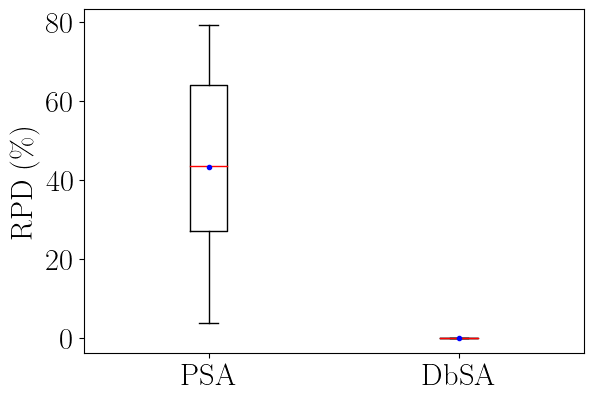


RPD-Werte für DCI – Algorithmus: PSA (absteigend sortiert):
                    Instance   DCI RPD
       a10_o128_m6_an51_ar13 79.246354
       a10_o107_m5_an57_ar12 65.363549
       a10_o114_m6_an57_ar11 65.115641
 a3_o80_m10_an10_ar9_reduced 63.464650
       a15_o170_m9_an80_ar18 53.227995
     a50_o578_m28_an276_ar66 44.078414
     a30_o355_m18_an148_ar42 42.669150
a5_o96_m10_an10_ar10_reduced 39.530516
     a25_o306_m13_an127_ar31 30.299971
     a20_o236_m12_an106_ar24 17.328928
       a10_o144_m6_an53_ar12 14.510023
     a40_o476_m22_an215_ar51  3.593088
  Algorithmus: PSA
    Q1: 27.0572
    Q2 (Median): 43.3738
    Mean: 43.2024
    Q3: 63.8774
    IQR: 36.8202
    Minimum: 3.5931
    Maximum: 79.2464
    Whisker min: 3.5931
    Whisker max: 79.2464
    Theoretical max whisker length (1.5 * IQR): 55.2303

RPD-Werte für DCI – Algorithmus: DbSA (absteigend sortiert):
                    Instance  DCI RPD
       a10_o107_m5_an57_ar12      0.0
       a10_o114_m6_an57_ar11      0.0

<Figure size 600x400 with 0 Axes>

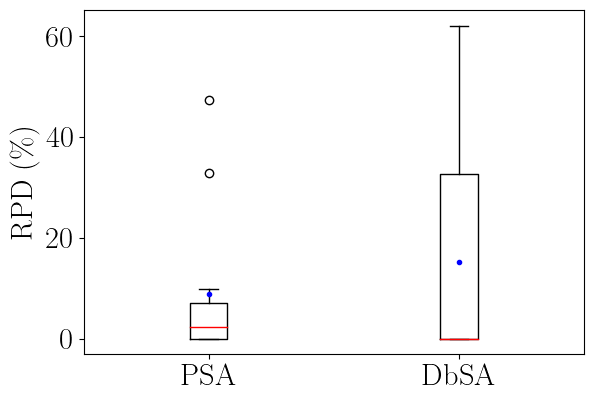


RPD-Werte für Hypevolume (Monte Carlo) – Algorithmus: PSA (absteigend sortiert):
                    Instance  Hypevolume (Monte Carlo) RPD
     a40_o476_m22_an215_ar51                     47.415476
       a10_o107_m5_an57_ar12                     32.746974
 a3_o80_m10_an10_ar9_reduced                      9.890258
       a10_o128_m6_an51_ar13                      6.068503
       a10_o114_m6_an57_ar11                      4.363658
a5_o96_m10_an10_ar10_reduced                      3.278808
       a10_o144_m6_an53_ar12                      1.479400
       a15_o170_m9_an80_ar18                      0.000000
     a20_o236_m12_an106_ar24                      0.000000
     a25_o306_m13_an127_ar31                      0.000000
     a30_o355_m18_an148_ar42                      0.000000
     a50_o578_m28_an276_ar66                      0.000000
  Algorithmus: PSA
    Q1: 0.0000
    Q2 (Median): 2.3791
    Mean: 8.7703
    Q3: 7.0239
    IQR: 7.0239
    Minimum: 0.0000
    Maximum: 47.4155
    

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 📐 Stil: LaTeX-kompatible Darstellung für Publikationen
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 22
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Instanzgröße extrahieren (optional für spätere Analysen)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🎯 Zielname
for objective in ["DCI", "Hypevolume (Monte Carlo)"]:
    # 🧮 RPD berechnen (Maximierungsproblem!)
    df["Best Value"] = df.groupby("Instance")[objective].transform("max")
    df[f"{objective} RPD"] = ((df["Best Value"] - df[objective]) / df["Best Value"]) * 100

    # 🧼 Methoden sortieren
    df["Algorithm"] = pd.Categorical(df["Algorithm"], categories=["PSA", "DbSA"], ordered=True)

    # 📦 Boxplot zeichnen
    plt.figure(figsize=(6, 4))
    df.boxplot(
        column=f"{objective} RPD",
        by="Algorithm",
        grid=False,
        showfliers=True,
        boxprops=dict(color="black"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="red"),
        meanprops=dict(marker='o', markerfacecolor='blue', markeredgecolor='blue', markersize=3),
        showmeans=True
    )

    # 🖼️ Achsen und Layout
    plt.title(f"RPD Distribution for {objective}", fontsize=12, pad=10)
    plt.title("")
    plt.suptitle("")
    #plt.xlabel("Method")
    plt.xlabel("")
    plt.ylabel("RPD (\%)")
    plt.tight_layout()

    # 💾 Optional: als PDF speichern
    #plt.savefig(f"rpd_boxplot_{objective.lower().replace(' ', '_')}.pdf", format="pdf", bbox_inches="tight", dpi=300)
    plt.show()
    ## RPD-Werte je Algorithmus sortiert nach Größe ausgeben
    for alg in df["Algorithm"].cat.categories:
        rpd_col = f"{objective} RPD"
        rpd_sorted = df[df["Algorithm"] == alg][["Instance", rpd_col]].sort_values(by=rpd_col, ascending=False)
        print(f"\nRPD-Werte für {objective} – Algorithmus: {alg} (absteigend sortiert):")
        print(rpd_sorted.to_string(index=False))
        values = df[df["Algorithm"] == alg][rpd_col]
        q1 = values.quantile(0.25)
        q2 = values.quantile(0.5)
        q3 = values.quantile(0.75)
        iqr = q3 - q1
        mean = values.mean()
        whisker_min = values[values >= (q1 - 1.5 * iqr)].min()
        whisker_max = values[values <= (q3 + 1.5 * iqr)].max()
        minimum = values.min()
        maximum = values.max()
        print(f"  Algorithmus: {alg}")
        print(f"    Q1: {q1:.4f}")
        print(f"    Q2 (Median): {q2:.4f}")
        print(f"    Mean: {mean:.4f}")
        print(f"    Q3: {q3:.4f}")
        print(f"    IQR: {iqr:.4f}")
        print(f"    Minimum: {minimum:.4f}")
        print(f"    Maximum: {maximum:.4f}")
        print(f"    Whisker min: {whisker_min:.4f}")
        print(f"    Whisker max: {whisker_max:.4f}")
        print(f"    Theoretical max whisker length (1.5 * IQR): {(1.5 * iqr):.4f}")

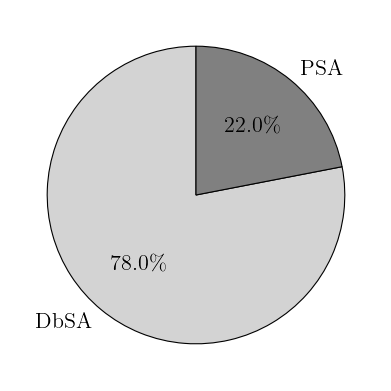

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 🎨 LaTeX-Stil aktivieren
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "figure.titlesize": 16
})

# 📂 CSV einlesen
df = pd.read_csv("Metrics_averaged.csv")

# 📊 Durchschnittlicher PF-Share je Algorithmus
pf_share_avg = df.groupby("Algorithm")["PF-Share"].mean()

# 📋 Labels mit Prozentangabe
labels = [f"{alg}" for alg in pf_share_avg.index]
colors = ["lightgray", "gray"]

# 🥧 Kreisdiagramm mit schwarzem Rand
fig, ax = plt.subplots(figsize=(4.8, 4.2))
wedges, texts, autotexts = ax.pie(
    pf_share_avg,
    labels=labels,
    colors=colors,
    startangle=90,
    autopct="%1.1f\\%%",
    textprops={"fontsize": 16},
    wedgeprops={"edgecolor": "black", "linewidth": 0.8}  # 🔲 schwarzer Rand
)

# 🖼️ Titel
#ax.set_title("Average PF-Share per Algorithm", fontsize=12)

# 💾 Optional speichern
#plt.savefig("pf_share_piechart_blackedge.pdf", bbox_inches="tight", dpi=300)

plt.tight_layout()
plt.show()